ge: 8.012e+09 Hz 

ef: 7.682e+09 Hz

In [1]:
from plottr.data.datadict_storage import datadict_from_hdf5
import numpy as np
import matplotlib.pyplot as plt
import lmfit

In [2]:
import sklearn
from sklearn.decomposition import PCA

In [3]:
def Lorentzian(freq, amp, const, center, k):
    return const - amp*k**2/((freq-center)**2 + k**2)

In [27]:
header = "D:/K_sunada/result/CDY158/"
# twotone(redout: 10.26GHz)
three_peak = "/2024-05-24/2024-05-24T114115_170ca298-cw_twotone" #drive: R.T.-40dB, lo power: -20~24dB, readout: R.T.: -30 dB, vna power: -10dB
ge_peak ="/2024-05-24/2024-05-24T125930_05dba96a-cw_twotone"#<ge>drive: R.T.-60dB, lo power: -20~10dB, readout: R.T.: -30 dB, vna power: -10dB
ef_peak = "/2024-05-24/2024-05-24T124524_0db1ccad-cw_twotone" #<ef>drive: R.T.-40dB, lo power: 0~24dB, readout: R.T.: -30 dB, vna power: -10dB


ge, ef peak

In [29]:
ddge = datadict_from_hdf5(header + ge_peak +"/data")
ddef = datadict_from_hdf5(header + ef_peak +"/data")

In [9]:
def PCA_transform(Re_c, Im_c):
    pca = PCA()
    c_data = np.concatenate([np.array([Re_c]).T, np.array([Im_c]).T], axis = 1)
    pca.fit(c_data)
    c_pca = pca.transform(c_data)
    c_PCA1 = c_pca.T[0]
    c_PCA2 = c_pca.T[1]
    return c_PCA1, c_PCA2

## ge遷移
初期値設定

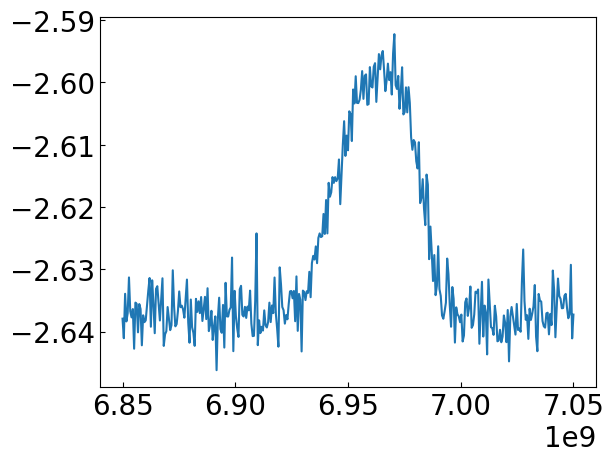

In [33]:
S11ge = ddge['s11']['values']
ge_phase = np.angle(S11ge)
freqge = ddge['frequency']['values']

y = ge_phase[0]
x = freqge[0]
plt.plot(x, y)
plt.show()

In [34]:
I = (S11ge.real)[0]
Q = (S11ge.imag)[0]
#c_data = np.concatenate([np.array([I]).T, np.array([Q]).T], axis = 1)

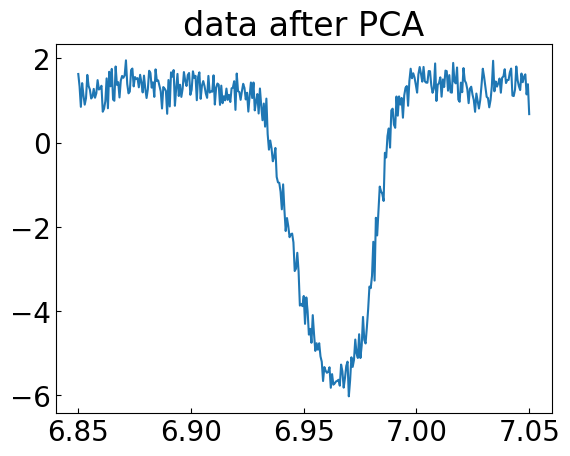

In [35]:
PCAge = PCA_transform(I, Q)
y = PCAge[0]*1e4
x = freqge[0]*1e-9

plt.plot(x, -y)
plt.title("data after PCA")
plt.show()

In [36]:
par_ini = {
    'amp': 7,
    'const':0.2,
    'center':6.97,
    'k':0.002
}

par_min = {
    'amp': 0,
    'const':0,
    'center':0,
    'k':0
}

par_max = {
    'amp': np.inf,
    'const':np.inf,
    'center':np.inf,
    'k':np.inf
}

par_vary = {
    'amp': True,
    'const':True,
    'center':True,
    'k':True
}

fitting

In [37]:
model = lmfit.Model(Lorentzian)

params = model.make_params()
for name in model.param_names:
    params[name].set(
    value = par_ini[name],
    min = par_min[name],
    max = par_max[name],
    vary = par_vary[name]
    )

In [38]:
result = model.fit(data = -y, params = params, freq = x)

In [39]:
result

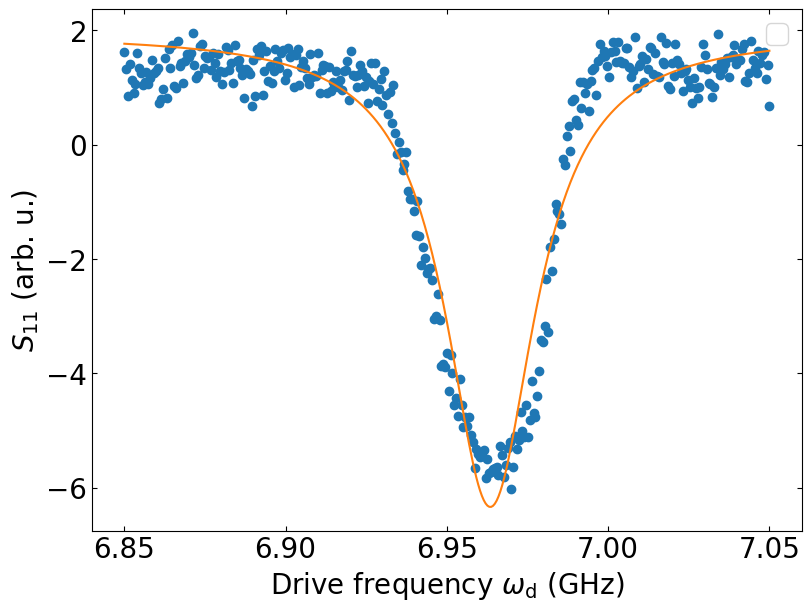

In [42]:
fig, ax = plt.subplots(figsize=(8,6),constrained_layout=True)
plt.rcParams["font.size"] = 20

plt.tick_params(top='on',bottom='on',left='on',right='on',)

plt.rcParams["xtick.direction"] = 'in'
plt.rcParams["ytick.direction"] = 'in'
result.plot_fit(ax = ax)
# plt.plot(x,result.init_fit)
# plt.xlim(7.95, 8.07)


plt.title("")
plt.legend("")
plt.xlabel("Drive frequency $\omega_\mathrm{d}$ (GHz)")
plt.ylabel("$S_{11}$ (arb. u.)")
# plt.savefig('ge_peak.png', bbox_inches='tight')
plt.show()

ef

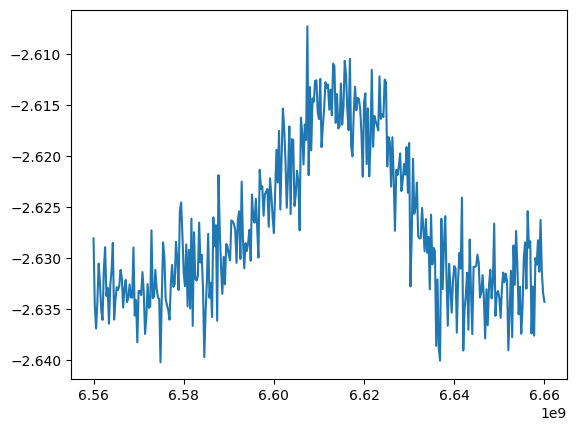

In [15]:
S11 = ddef['s11']['values']
phase = np.angle(S11)
freq = ddef['frequency']['values']

y = phase[5]
x = freq[5]
plt.plot(x, y)
plt.show()

In [17]:
I = (S11.real)[5]
Q = (S11.imag)[5]
#c_data = np.concatenate([np.array([I]).T, np.array([Q]).T], axis = 1)

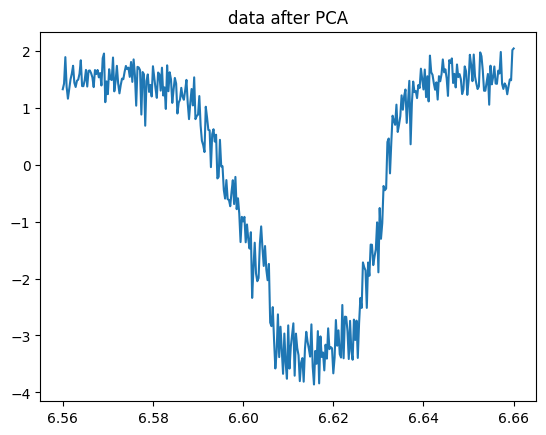

In [19]:
PCAef = PCA_transform(I, Q)
y = PCAef[0]*1e4
x = freq[0]*1e-9

plt.plot(x, -y)
plt.title("data after PCA")
plt.show()

In [20]:
par_ini = {
    'amp': 5,
    'const':0.2,
    'center':6.618,
    'k':0.002
}

par_min = {
    'amp': 0,
    'const':0,
    'center':0,
    'k':0
}

par_max = {
    'amp': np.inf,
    'const':np.inf,
    'center':np.inf,
    'k':np.inf
}

par_vary = {
    'amp': True,
    'const':True,
    'center':True,
    'k':True
}

In [21]:
model = lmfit.Model(Lorentzian)

params = model.make_params()
for name in model.param_names:
    params[name].set(
    value = par_ini[name],
    min = par_min[name],
    max = par_max[name],
    vary = par_vary[name]
    )

In [22]:
result = model.fit(data = -y, params = params, freq = x)

In [23]:
result

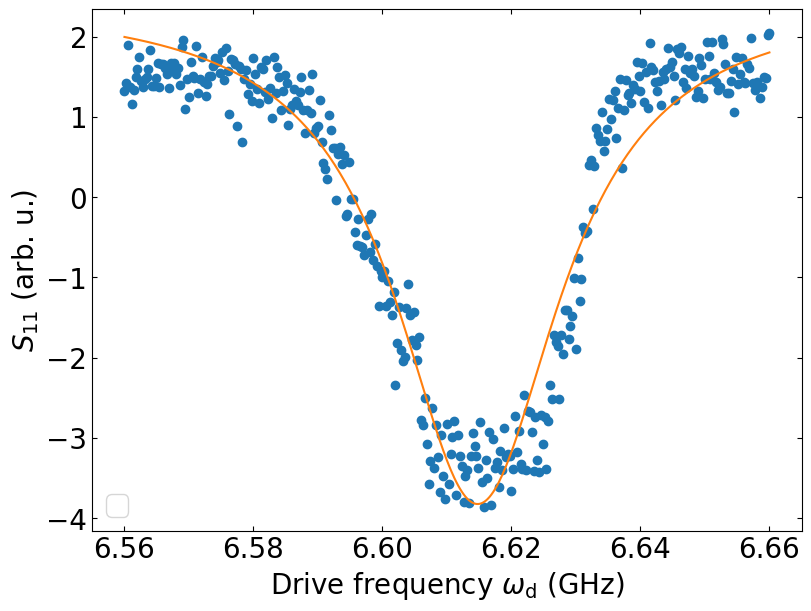

In [26]:
fig, ax = plt.subplots(figsize=(8,6),constrained_layout=True)
plt.rcParams["font.size"] = 20

plt.tick_params(top='on',bottom='on',left='on',right='on',)

plt.rcParams["xtick.direction"] = 'in'
plt.rcParams["ytick.direction"] = 'in'
result.plot_fit(ax = ax)
# plt.plot(x,result.init_fit)
# plt.xlim(7.95, 8.07)


plt.title("")
plt.legend("")
plt.xlabel("Drive frequency $\omega_\mathrm{d}$ (GHz)")
plt.ylabel("$S_{11}$ (arb. u.)")
# plt.savefig('ge_peak.png', bbox_inches='tight')
plt.show()